In [1]:
using Accessors
using Gen
using Compose
using PhySMC
using PhyBullet
using PyCall
using Parameters
using DocStringExtensions
using Distributions
using LinearAlgebra
using Random
using Statistics
using Plots

pybullet build time: Oct 21 2025 11:20:22


In [2]:
function ramp(mass_ratio::Float64, obj_frictions::NTuple{2, Float64} = (.5, .5), obj_positions::NTuple{2, Float64} = (0.5, 1.5), slope::Float64=2/3, tableRampIntersection::Float64=0.0)
    
    # for debugging
    #client = @pycall pb.connect(pb.GUI)::Int64
    #pb.resetDebugVisualizerCamera(4.5, 0, -40, [0.0, 0.0, 0.0]; physicsClientId=client)

    # Set up the pybullet client and set gravity at -10
    client = @pycall pb.connect(pb.DIRECT)::Int64
    pb.setGravity(0,0,-10; physicsClientId = client)


    # add a table base (setting mass = 0 makes it a static object)
    grey = [0.5, 0.5, 0.5, 1]
    base_dims = [5, 1, 0.75] # in meters
    table_dims = [base_dims[1] + 0.2, base_dims[2] + 0.2, 0.1]  # Width, depth, height
    table_base_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents = base_dims / 2, physicsClientId = client)
    table_base_obj_id = pb.createMultiBody(baseCollisionShapeIndex = table_base_col_id, basePosition = [0,0,-(base_dims[3]+table_dims[3])/2], physicsClientId = client)
    pb.changeDynamics(table_base_obj_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_base_obj_id, -1, rgbaColor=grey, physicsClientId=client)

    # Create the tabletop (a flat box)
    table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=table_dims/2)
    table_body_id = pb.createMultiBody(baseCollisionShapeIndex=table_col_id, basePosition=[0, 0, -table_dims[3]/2])
    pb.changeDynamics(table_body_id, -1; mass = 0., restitution = 0.9, physicsClientId=client)
    pb.changeVisualShape(table_body_id, -1, rgbaColor=grey.+0.2, physicsClientId=client)

    # Create the four frame-like boxes around the tabletop
    frame_height = 0.25
    frame_thickness = 0.05

    frame_dims = [
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [table_dims[1] + 2 * frame_thickness, frame_thickness, frame_height],  # Longer sides
        [frame_thickness, table_dims[2], frame_height],  # Shorter sides
        [frame_thickness, table_dims[2], frame_height]  # Shorter sides
    ]

    frame_positions = [
        [0, table_dims[2] / 2 + frame_thickness / 2, 0],  # Top side
        [0, -table_dims[2] / 2 - frame_thickness / 2, 0],  # Bottom side
        [table_dims[1] / 2 + frame_thickness / 2, 0, 0],  # Right side
        [-table_dims[1] / 2 - frame_thickness / 2, 0, 0]  # Left side
    ]

    for (dims, pos) in zip(frame_dims, frame_positions)
        frame_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims/2)::Int64
        frame_obj_id = pb.createMultiBody(baseCollisionShapeIndex=frame_col_id, basePosition=pos)::Int64
        pb.changeVisualShape(frame_obj_id, -1, rgbaColor=grey, physicsClientId=client)
    end

    # add a ramp
    pb.setAdditionalSearchPath("/gpfs/radev/project/yildirim/aa2842/minimum-simulation-capsules")
    ramp_col_id = pb.createCollisionShape(pb.GEOM_MESH, fileName="/assets/ramp.obj", physicsClientId=client, meshScale=[2, base_dims[2], slope*2])
    ramp_position = [-2+tableRampIntersection, -base_dims[2]/2, 0]
    ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=ramp_col_id, basePosition=ramp_position, physicsClientId=client)
    pb.changeDynamics(ramp_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
    pb.changeVisualShape(ramp_obj_id, -1, rgbaColor=[1, 1, 1, 1], physicsClientId=client)

    # add a floor
    floor_col_id = pb.createCollisionShape(pb.GEOM_PLANE, physicsClientId=client)
    floor_obj_id = pb.createMultiBody(baseCollisionShapeIndex=floor_col_id, basePosition=[0,0,-base_dims[3]], physicsClientId=client)
    pb.changeDynamics(floor_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)


    #  add walls
    wall_dims = [[0.1, 8.0, 5.0], [0.1, 8.0, 5.0], [8.0, 0.1, 5.0]] # Width, length, height
    wall_positions = [
        [4.0, 0.0, 1.0],  # Right Wall
        [-4.0, 0.0, 1.0],  # Left Wall
        [0, 4, wall_dims[3][3]/2-base_dims[3]] # Back Wall
    ]
    for (dims, pos) in zip(wall_dims, wall_positions)
        wall_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=dims./2, physicsClientId=client)
        wall_obj_id = pb.createMultiBody(baseCollisionShapeIndex=wall_col_id, basePosition=pos, physicsClientId=client)
        pb.changeDynamics(wall_obj_id, -1; mass=0.0, restitution=0.9, physicsClientId=client)
        pb.changeVisualShape(wall_obj_id, -1, rgbaColor=grey+[0.2, 0.2, 0.2, 0], physicsClientId=client)
    end

    # add an object on the ramp
    obj_ramp_dims = [0.15, 0.3, 0.075]
    theta_radians = -atan(slope)
    orientation = [cos(theta_radians / 2), 0, sin(theta_radians / 2), 0]

    obj_on_ramp_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_ramp_dims/2, physicsClientId=client)
    lift = obj_ramp_dims[3]/2
    position = [
        -2+2*obj_positions[1]+tableRampIntersection+lift*cos(theta_radians),
        0,
        (2-2*obj_positions[1])*slope-lift*sin(theta_radians)
    ]
    obj_on_ramp_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_ramp_col_id, basePosition=position, baseOrientation=orientation, physicsClientId=client)
    pb.changeDynamics(obj_on_ramp_obj_id, -1; mass=mass_ratio, restitution=0.9, lateralFriction=obj_frictions[1], physicsClientId=client)
    
    # add an object on the table that will collide with the object on the ramp as that one slides down
    obj_on_table_dims = [0.2, 0.2, 0.1]
    obj_on_table_col_id = pb.createCollisionShape(pb.GEOM_BOX, halfExtents=obj_on_table_dims/2, physicsClientId=client)
    obj_on_table_obj_id = pb.createMultiBody(baseCollisionShapeIndex=obj_on_table_col_id, basePosition=[2.5*(obj_positions[2]-1), 0, obj_on_table_dims[3]/2], physicsClientId=client)
    pb.changeDynamics(obj_on_table_obj_id, -1; mass=1.0, restitution=0.9, lateralFriction=obj_frictions[2], physicsClientId=client)

    (client, obj_on_ramp_obj_id, obj_on_table_obj_id)
end

ramp (generic function with 5 methods)

In [4]:
# Declare constants and create a scene
mass_ratio = 7.0
obj_frictions = (0.3, 0.3)
obj_positions = (0.5, 1.5)

client, obj_1, obj_2 = ramp(mass_ratio, obj_frictions, obj_positions)

(0, 11, 12)

In [5]:
# create PhySMC and PhyBullet objects
sim = BulletSim(; client=client)
obj_r = RigidBody(obj_1)           # ramp obj
obj_t = RigidBody(obj_2)           # table obj

# get an initial state (to be overwritten in the prior function)
init_state = BulletState(sim, [obj_r, obj_t]);

In [6]:
# ----------------------------
# Tunable predicate parameters
# ----------------------------

# Maximum gap at which the objects count as "near"
gap_max = 0.10

# Softness of the gap gate
gap_scale = 0.025

# Minimum closing speed required to count as approaching
v_min = 0.02

# Softness of the closing-speed gate
v_scale = 0.02

# Contact prediction horizon.
# If using seconds, this is seconds. If using simulation steps, convert accordingly below.
T_contact = 0.25

# Softness of the time-to-contact gate
tau_scale = 0.05

# Base probability of birthing a collision capsule when all predicates are satisfied
p0 = 0.95

# Numerical safety
eps_v = 1e-6
eps_d = 1e-9

# If true, birth probability is forced to 0 after actual collision is detected
suppress_after_collision = true

# ----------------------------
# Object shape constants
# copied from ramp(...)
# ----------------------------

obj_ramp_dims  = [0.15, 0.3, 0.075]
obj_table_dims = [0.2,  0.2, 0.1]

# For a simple first pass, use bounding-sphere radii.
# This is conservative and easy to inspect.
R_ramp  = norm(obj_ramp_dims) / 2
R_table = norm(obj_table_dims) / 2

R_sum = R_ramp + R_table

# Logistic squashing function
σ(z) = 1 / (1 + exp(-z))

σ (generic function with 1 method)

In [7]:
state = init_state

println("BulletState fields:")
println(propertynames(state))

println("\nKinematics object 1 fields:")
println(propertynames(state.kinematics[1]))

println("\nKinematics object 2 fields:")
println(propertynames(state.kinematics[2]))

println("\nObject 1 kinematics:")
display(state.kinematics[1])

println("\nObject 2 kinematics:")
display(state.kinematics[2])

BulletState fields:
(:elements, :latents, :kinematics)

Kinematics object 1 fields:
(:position, :orientation, :linear_vel, :angular_vel, :aabb)

Kinematics object 2 fields:
(:position, :orientation, :linear_vel, :angular_vel, :aabb)

Object 1 kinematics:


RigidBodyState([-0.9687981139623308, 0.0, 0.6874679240251127], [0.9570920264890528, 0.0, -0.2897841486884301, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], StaticArraysCore.SVector{3, Float64}[[-1.0520031433961152, -0.15, 0.6146635232705514], [-0.8855930845285465, 0.15, 0.760272324779674]])


Object 2 kinematics:


RigidBodyState([1.25, 0.0, 0.05], [0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0], StaticArraysCore.SVector{3, Float64}[[1.15, -0.1, 0.0], [1.35, 0.1, 0.1]])

In [8]:
state = init_state

# --------------------------------------------------------
# Extract positions and velocities from the BulletState
# Change these field names if introspection shows different names.
# --------------------------------------------------------

x_r = Vector{Float64}(state.kinematics[1].position)
x_t = Vector{Float64}(state.kinematics[2].position)

v_r = Vector{Float64}(state.kinematics[1].linear_vel)
v_t = Vector{Float64}(state.kinematics[2].linear_vel)

# --------------------------------------------------------
# Relative kinematics
# --------------------------------------------------------

r = x_t - x_r                  # vector from ramp object to table object
d = norm(r)                    # center-to-center distance
rhat = r / max(d, eps_d)        # unit direction from ramp object to table object

u = v_t - v_r                  # velocity of table object relative to ramp object

# Positive means the objects are moving toward each other.
v_closing = -dot(u, rhat)

# --------------------------------------------------------
# Surface gap
# --------------------------------------------------------
# First-pass approximation:
# center distance minus bounding-sphere radii.
#
# For your ramp scene this is good enough as a predicate diagnostic,
# but eventually you may want PyBullet closest-point distance instead.

gap = d - R_sum

# Clamp only for tau calculation.
# The raw gap is still useful to plot.
gap_for_tau = max(gap, 0.0)

# --------------------------------------------------------
# Constant-velocity time-to-contact
# --------------------------------------------------------

tau = gap_for_tau / max(v_closing, eps_v)

# --------------------------------------------------------
# Soft predicate gates
# --------------------------------------------------------

p_gap = σ((gap_max - gap) / gap_scale)

p_closing = σ((v_closing - v_min) / v_scale)

p_ttc = σ((T_contact - tau) / tau_scale)

# For now, assume no active collision capsule already exists.
# In the actual generative model, set this from your capsule set.
already_active_collision = false
p_inactive = already_active_collision ? 0.0 : 1.0

p_birth = p0 * p_inactive * p_gap * p_closing * p_ttc

# --------------------------------------------------------
# Inspect everything
# --------------------------------------------------------

println("x_r = ", x_r)
println("x_t = ", x_t)
println("v_r = ", v_r)
println("v_t = ", v_t)
println("r = ", r)
println("d = ", d)
println("gap = ", gap)
println("v_closing = ", v_closing)
println("tau = ", tau)
println("p_gap = ", p_gap)
println("p_closing = ", p_closing)
println("p_ttc = ", p_ttc)
println("p_birth = ", p_birth)

x_r = [-0.9687981139623308, 0.0, 0.6874679240251127]
x_t = [1.25, 0.0, 0.05]
v_r = [0.0, 0.0, 0.0]
v_t = [0.0, 0.0, 0.0]
r = [2.2187981139623307, 0.0, -0.6374679240251127]
d = 2.3085559175995027
gap = 1.9867093290386588
v_closing = -0.0
tau = 1.9867093290386589e6
p_gap = 1.6768799720413817e-33
p_closing = 0.2689414213699951
p_ttc = 0.0
p_birth = 0.0


In [10]:
# Number of simulation steps to inspect
T = 120

states = Vector{Any}(undef, T + 1)
states[1] = init_state

for t in 1:T
    states[t + 1] = PhySMC.step(sim, states[t])
end

# Storage
ts = collect(0:T)

x_r_hist = Vector{Vector{Float64}}(undef, T + 1)
x_t_hist = Vector{Vector{Float64}}(undef, T + 1)

v_r_hist = Vector{Vector{Float64}}(undef, T + 1)
v_t_hist = Vector{Vector{Float64}}(undef, T + 1)

gap_hist = zeros(T + 1)
v_closing_hist = zeros(T + 1)
tau_hist = zeros(T + 1)

p_gap_hist = zeros(T + 1)
p_closing_hist = zeros(T + 1)
p_ttc_hist = zeros(T + 1)
p_birth_hist = zeros(T + 1)

collision_hist = falses(T + 1)

already_active_collision = false

for idx in eachindex(states)
    state = states[idx]

    # --------------------------------------------------------
    # Extract state
    # --------------------------------------------------------

    x_r = Vector{Float64}(state.kinematics[1].position)
    x_t = Vector{Float64}(state.kinematics[2].position)

    v_r = Vector{Float64}(state.kinematics[1].linear_vel)
    v_t = Vector{Float64}(state.kinematics[2].linear_vel)

    x_r_hist[idx] = x_r
    x_t_hist[idx] = x_t
    v_r_hist[idx] = v_r
    v_t_hist[idx] = v_t

    # --------------------------------------------------------
    # Relative kinematics
    # --------------------------------------------------------

    r = x_t - x_r
    d = norm(r)
    rhat = r / max(d, eps_d)

    u = v_t - v_r
    v_closing = -dot(u, rhat)

    # --------------------------------------------------------
    # Surface gap approximation
    # --------------------------------------------------------

    gap = d - R_sum

    # Collision is when approximate surface gap reaches/crosses zero.
    # Later replace this with PyBullet contact/closest-point logic if needed.
    is_colliding_now = gap <= 0.0
    collision_hist[idx] = is_colliding_now

    # --------------------------------------------------------
    # Constant-velocity time-to-contact
    # --------------------------------------------------------

    gap_for_tau = max(gap, 0.0)
    tau = gap_for_tau / max(v_closing, eps_v)

    # --------------------------------------------------------
    # Soft gates
    # --------------------------------------------------------

    p_gap = σ((gap_max - gap) / gap_scale)
    p_closing = σ((v_closing - v_min) / v_scale)
    p_ttc = σ((T_contact - tau) / tau_scale)

    if suppress_after_collision && already_active_collision
        p_inactive = 0.0
    else
        p_inactive = 1.0
    end

    p_birth = p0 * p_inactive * p_gap * p_closing * p_ttc

    # Once true contact happens, pretend the collision capsule has become active.
    # This mimics "do not birth another collision capsule for the same pair."
    if is_colliding_now
        already_active_collision = true
    end

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    gap_hist[idx] = gap
    v_closing_hist[idx] = v_closing
    tau_hist[idx] = tau

    p_gap_hist[idx] = p_gap
    p_closing_hist[idx] = p_closing
    p_ttc_hist[idx] = p_ttc
    p_birth_hist[idx] = p_birth
end

# First estimated collision time
collision_indices = findall(collision_hist)

collision_idx = isempty(collision_indices) ? nothing : first(collision_indices)
collision_t = collision_idx === nothing ? nothing : ts[collision_idx]

println("Estimated collision time = ", collision_t)

Estimated collision time = 60


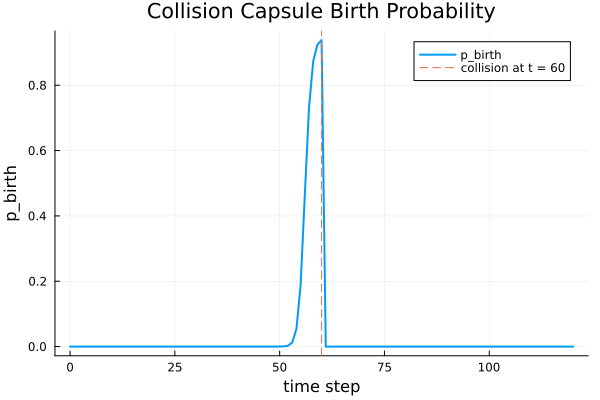

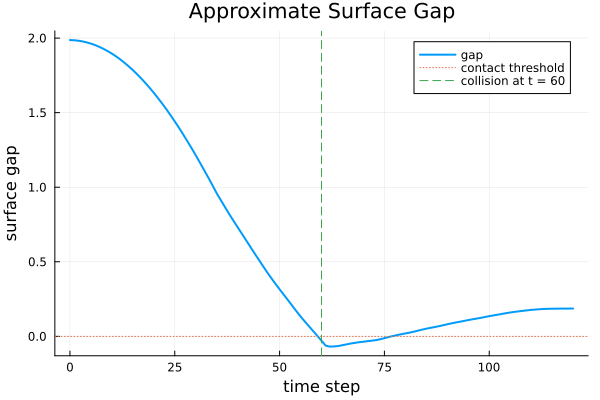

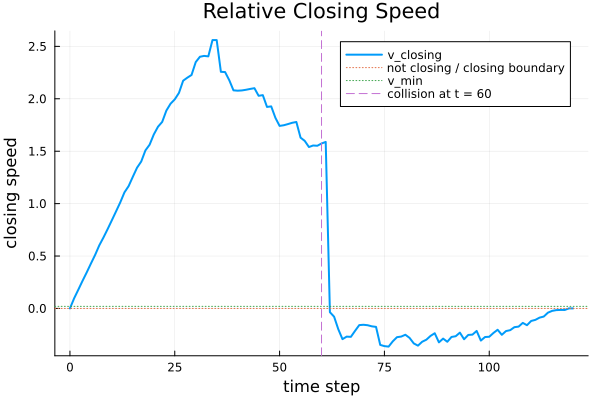

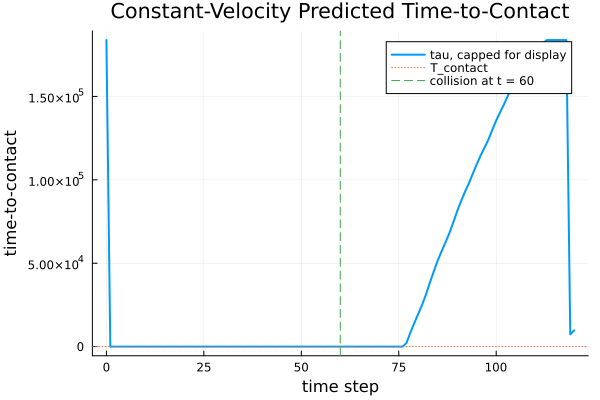

In [11]:
# Helper values for plotting
collision_label = collision_t === nothing ? "no collision detected" : "collision at t = $collision_t"

# For tau, avoid plot being ruined by huge values when objects are not closing.
tau_plot = copy(tau_hist)
tau_cap = quantile(tau_plot[isfinite.(tau_plot)], 0.95)
tau_plot = min.(tau_plot, tau_cap)

# ----------------------------
# Plot 1: p_birth
# ----------------------------

plt1 = plot(
    ts,
    p_birth_hist,
    xlabel = "time step",
    ylabel = "p_birth",
    title = "Collision Capsule Birth Probability",
    legend = :topright,
    label = "p_birth",
    linewidth = 2
)

if collision_t !== nothing
    vline!(plt1, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt1)

# ----------------------------
# Plot 2: gap
# ----------------------------

plt2 = plot(
    ts,
    gap_hist,
    xlabel = "time step",
    ylabel = "surface gap",
    title = "Approximate Surface Gap",
    legend = :topright,
    label = "gap",
    linewidth = 2
)

hline!(plt2, [0.0], label = "contact threshold", linestyle = :dot)

if collision_t !== nothing
    vline!(plt2, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt2)

# ----------------------------
# Plot 3: v_closing
# ----------------------------

plt3 = plot(
    ts,
    v_closing_hist,
    xlabel = "time step",
    ylabel = "closing speed",
    title = "Relative Closing Speed",
    legend = :topright,
    label = "v_closing",
    linewidth = 2
)

hline!(plt3, [0.0], label = "not closing / closing boundary", linestyle = :dot)
hline!(plt3, [v_min], label = "v_min", linestyle = :dot)

if collision_t !== nothing
    vline!(plt3, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt3)

# ----------------------------
# Plot 4: tau
# ----------------------------

plt4 = plot(
    ts,
    tau_plot,
    xlabel = "time step",
    ylabel = "time-to-contact",
    title = "Constant-Velocity Predicted Time-to-Contact",
    legend = :topright,
    label = "tau, capped for display",
    linewidth = 2
)

hline!(plt4, [T_contact], label = "T_contact", linestyle = :dot)

if collision_t !== nothing
    vline!(plt4, [collision_t], label = collision_label, linestyle = :dash)
end

display(plt4)

In [12]:
# A compact table-like object for debugging
predicate_history = [
    (
        t = ts[i],
        p_birth = p_birth_hist[i],
        gap = gap_hist[i],
        v_closing = v_closing_hist[i],
        tau = tau_hist[i],
        p_gap = p_gap_hist[i],
        p_closing = p_closing_hist[i],
        p_ttc = p_ttc_hist[i],
        collision = collision_hist[i]
    )
    for i in eachindex(ts)
]

# Look near the first collision if one exists
if collision_idx !== nothing
    lo = max(collision_idx - 10, 1)
    hi = min(collision_idx + 10, length(predicate_history))
    display(predicate_history[lo:hi])
else
    display(predicate_history[1:min(20, length(predicate_history))])
end

21-element Vector{NamedTuple{(:t, :p_birth, :gap, :v_closing, :tau, :p_gap, :p_closing, :p_ttc, :collision), Tuple{Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Bool}}}:
 (t = 50, p_birth = 0.00013591028871289167, gap = 0.3156638241817957, v_closing = 1.7414094127764568, tau = 0.18126916155719505, p_gap = 0.0001792494345945922, p_closing = 1.0, p_ttc = 0.7981250380321141, collision = 0)
 (t = 51, p_birth = 0.0006255399693191304, gap = 0.27930907282004214, v_closing = 1.7476316647151178, tau = 0.1598214763781889, p_gap = 0.0007669184194259821, p_closing = 1.0, p_ttc = 0.8585830108134928, collision = 0)
 (t = 52, p_birth = 0.002833181298416546, gap = 0.2427635045801252, v_closing = 1.7588128697449472, tau = 0.13802690937514536, p_gap = 0.0032999578019610835, p_closing = 1.0, p_ttc = 0.9037376483493392, collision = 0)
 (t = 53, p_birth = 0.012639202500651573, gap = 0.20596588218087974, v_closing = 1.771008415195484, tau = 0.11629864681255353, p_gap = 0.014222081713